In [23]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pywt
from pylab import mpl
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams['figure.constrained_layout.use'] = False # 禁用


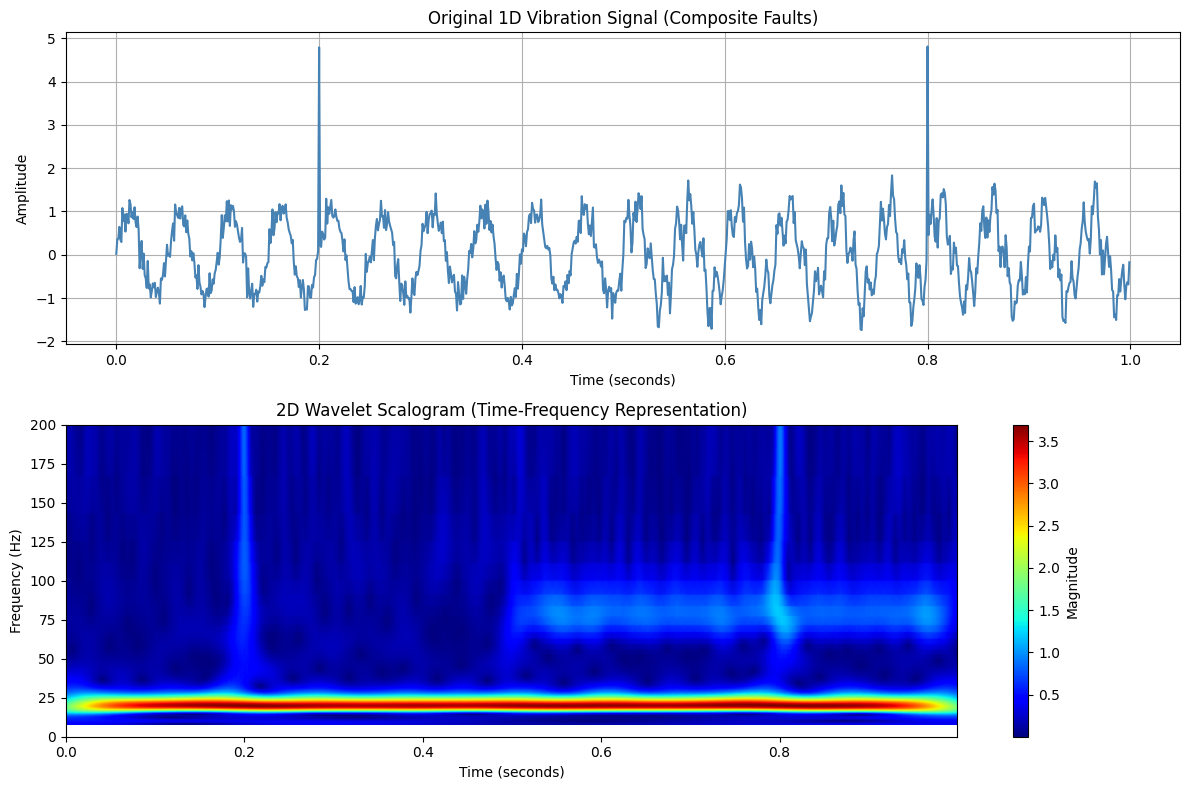

In [127]:

# ==========================================
# 第一步：生成模拟的“机器振动信号”
# ==========================================
# 采样频率和时间向量
fs = 1000  # 采样率 1000 Hz
t = np.linspace(0, 1, fs, endpoint=False) # 1秒钟的信号

# 1. 低频基线信号 (模拟机器正常运转的背景噪音，20Hz)
signal_normal = np.sin(2 * np.pi * 20 * t)

# 2. 高频突变信号 (模拟机器在 0.5秒 时突然发生的高频振动，80Hz)
signal_high_freq = np.zeros_like(t)
signal_high_freq[500:] = 0.5 * np.sin(2 * np.pi * 80 * t[500:]) 

# 3. 瞬态冲击信号 (模拟齿轮断齿或轴承裂纹在 0.2秒和 0.8秒时的瞬间撞击)
impacts = np.zeros_like(t)
impacts[200] = 5  # 0.2秒处的强冲击
impacts[800] = 5  # 0.8秒处的强冲击

# 合成最终的复合信号，并加入一点随机白噪声
signal_composite = signal_normal + signal_high_freq + impacts + np.random.normal(0, 0.2, len(t))

# ==========================================
# 第二步：执行连续小波变换 (CWT)
# ==========================================
# 选择小波基函数：这里选用复 Morlet 小波 ('cmor')，它在故障诊断中非常经典
wavelet_name = 'cmor1.5-1.0' 

# 定义我们要观察的尺度 (Scales)。尺度越小，对应频率越高；尺度越大，对应频率越低。
scales = np.arange(1, 128)

# 执行连续小波变换
# cwtmatr 包含了变换后的复数矩阵（即时频特征），frequencies 是对应的实际频率
coefficients, frequencies = pywt.cwt(signal_composite, scales, wavelet_name, sampling_period=1/fs)

# 取绝对值（振幅），用于可视化
amplitude_scalogram = np.abs(coefficients)

# ==========================================
# 第三步：可视化结果
# ==========================================
plt.figure(figsize=(12, 8))

# 绘制原始一维信号
plt.subplot(2, 1, 1)
plt.plot(t, signal_composite, color='steelblue')
plt.title("Original 1D Vibration Signal (Composite Faults)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)

# 绘制小波变换后的二维时频图 (Scalogram)

plt.subplot(2, 1, 2)
# 使用 pcolormesh 绘制热力图
plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
plt.title("2D Wavelet Scalogram (Time-Frequency Representation)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Magnitude")
plt.ylim(0, 200) # 限制 Y 轴显示范围以便看得更清楚

plt.tight_layout()
plt.show()

In [2]:
file_path='../数据集/BJTU/外圈/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv'
def data_load(file_path):
    df=pd.read_csv(file_path,usecols=['CH17'])
    df=df.iloc[:,0].values
    return df

In [3]:
data=data_load(file_path)
data=data[:64000]

In [4]:
def wav_trans(fs,wavelet_name,data):
    # 选择小波基函数：这里选用复 Morlet 小波 ('cmor')，它在故障诊断中非常经典
    
    # 定义我们要观察的尺度 (Scales)。尺度越小，对应频率越高；尺度越大，对应频率越低。
    scales = np.arange(1, 128)
    
    # 执行连续小波变换
    # cwtmatr 包含了变换后的复数矩阵（即时频特征），frequencies 是对应的实际频率
    coefficients, frequencies = pywt.cwt(data, scales, wavelet_name, sampling_period=1/fs)
    
    # 取绝对值（振幅），用于可视化
    amplitude_scalogram = np.abs(coefficients)
    return  frequencies,amplitude_scalogram

In [5]:
fs=64000 #fs 采样频率
frequencies,amplitude_scalogram=wav_trans(fs,wavelet_name='cgau8',data=data)

In [6]:
# 绘制原始一维信号
def plot(data,frequencies,amplitude_scalogram):
    plt.subplot(2, 1, 1)
    t = np.linspace(0, 1, fs, endpoint=False)
    plt.plot(t, data, color='steelblue')
    plt.title("Original 1D Vibration Signal (Composite Faults)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    
    # 绘制小波变换后的二维时频图 (Scalogram)
    
    plt.subplot(2, 1, 2)
    # 使用 pcolormesh 绘制热力图
    plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
    plt.title("2D Wavelet Scalogram (Time-Frequency Representation)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")
    plt.ylim(500,10000) # 把上限从 60000 多压到 15000 左右（可根据实际亮斑位置微调）
    
    plt.tight_layout()
    plt.show()

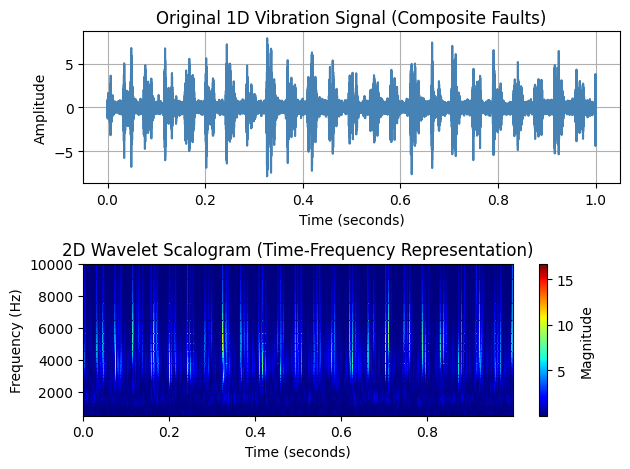

In [7]:
plot(data, frequencies, amplitude_scalogram)

In [8]:
#选取不同的小波
wavename=['cgau8','morl','cmor1-1','cmor1.5-2']
sampling_rate=64000
#选取不同小波函数以及参数
def select_pywt(data,wavename):
    totalscal=128
    fc=pywt.central_frequency(wavename)
    cparam=2*fc*totalscal
    scale=cparam/np.arange(totalscal,0,-1)
    
    coefficients, frequencies = pywt.cwt(data, scale, wavename, 1/sampling_rate)
    amplitude_scalogram = np.abs(coefficients)
    return frequencies,amplitude_scalogram

In [13]:
def plot(wavename,data,frequencies,amplitude_scalogram):
    plt.subplot(2, 1, 1)
    t = np.linspace(0, 1, fs, endpoint=False)
    plt.plot(t, data, color='steelblue')
    plt.title("Original 1D Vibration Signal (Composite Faults)")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    # 绘制小波变换后的二维时频图 (Scalogram)
    plt.subplot(2, 1, 2)
    # 使用 pcolormesh 绘制热力图
    plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
    plt.title(f"2D Wavelet Scalogram (故障-{wavename})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")
    plt.ylim(500,10000) # 把上限从 60000 多压到 15000 左右（可根据实际亮斑位置微调）
    plt.tight_layout()
    plt.show()

C:\Users\wwt29\AppData\Local\Temp\ipykernel_25348\1968276392.py:18: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


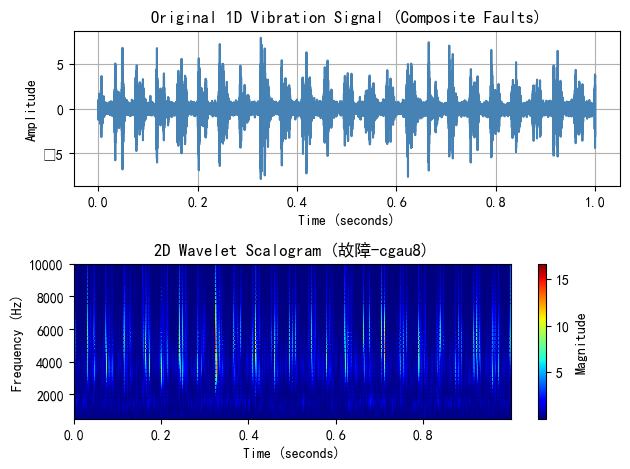

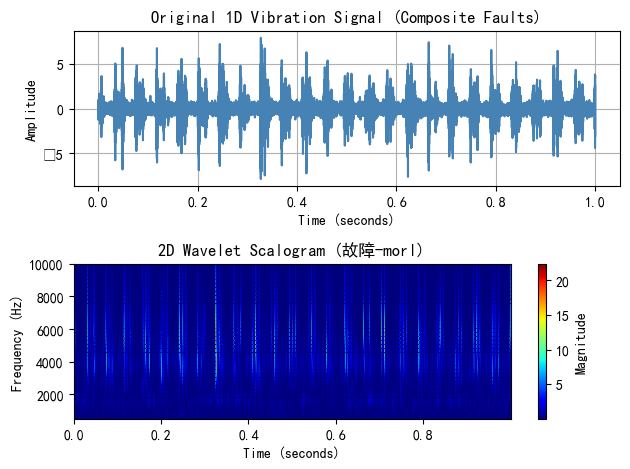

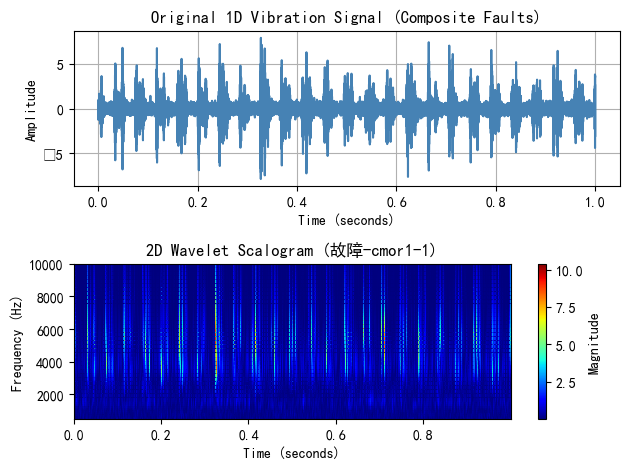

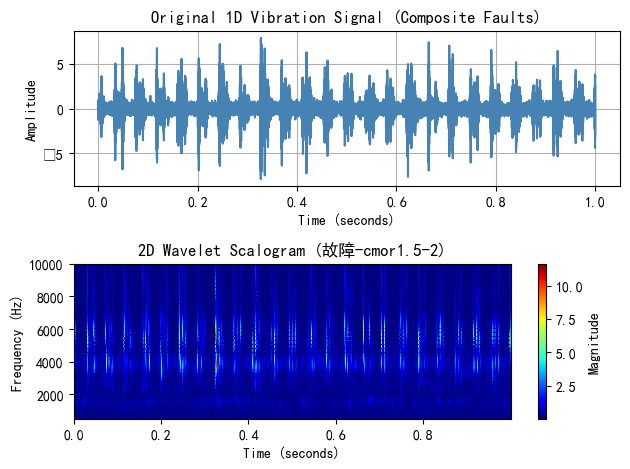

In [14]:
data=data_load(file_path)
data=data[:64000]
for i in range(len(wavename)):
    frequencies,amplitude_scalogram=select_pywt(data,wavename[i])
    plot(wavename[i], data, frequencies, amplitude_scalogram)

In [ ]:
#处理不同工况的故障

In [39]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def process_folder(folder_path):
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.csv')])
    cols = 3
    rows = (len(files) + cols - 1) // cols
    
    # 创建画布和子图矩阵
    fig, axes = plt.subplots(rows, cols, figsize=(30, 6 * rows), constrained_layout=True)
    
    # 将多维的 axes 矩阵展平为一维数组，方便用 axes[i] 循环调用
    # 使用 np.atleast_1d 防止只有一个文件时 flatten() 报错
    axes = np.atleast_1d(axes).flatten() 
    
    fs = 64000
    t = np.linspace(0, 1, fs, endpoint=False)
    
    for i, file_name in enumerate(files):
        # 1. 自动从文件名解析频率
        motor_f = float(file_name.split('Hz')[0].split('_')[-1])
        df = pd.read_csv(os.path.join(folder_path, file_name), usecols=['CH17'])
        data = df.iloc[:64000, 0].values
        
        # 【修改点 1】: 必须接收 select_pywt 返回的频率和图像矩阵
        frequencies, amplitude_scalogram = select_pywt(data, 'cgau8')
        
        # 【修改点 2】: 移除 .plt，将 pcolormesh 赋值给 im，方便后面画颜色条
        im = axes[i].pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
        
        # 【修改点 3】: 子图对象设置标题、坐标轴的语法前面要加 'set_'
        axes[i].set_title(f"({file_name}-cgau8)")
        axes[i].set_xlabel("Time (seconds)")
        axes[i].set_ylabel("Frequency (Hz)")
        axes[i].set_ylim(0, 10000) 
        
        # 【修改点 4】: 在子图上画 Colorbar 需要指定 fig 和对应的 ax
        fig.colorbar(im, ax=axes[i], label="Magnitude")
        
        print(f"Processed: {file_name}")

    # 【新增细节】: 如果文件数量不是 3 的倍数，隐藏最后几个多余的空白画框
    for j in range(len(files), len(axes)):
        axes[j].axis('off')
        
    plt.show()

Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_20Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_40Hz_0kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_+10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_-10kN.csv
Processed: data_leftaxlebox_M0_G0_LA2_RA0_60Hz_0kN.csv


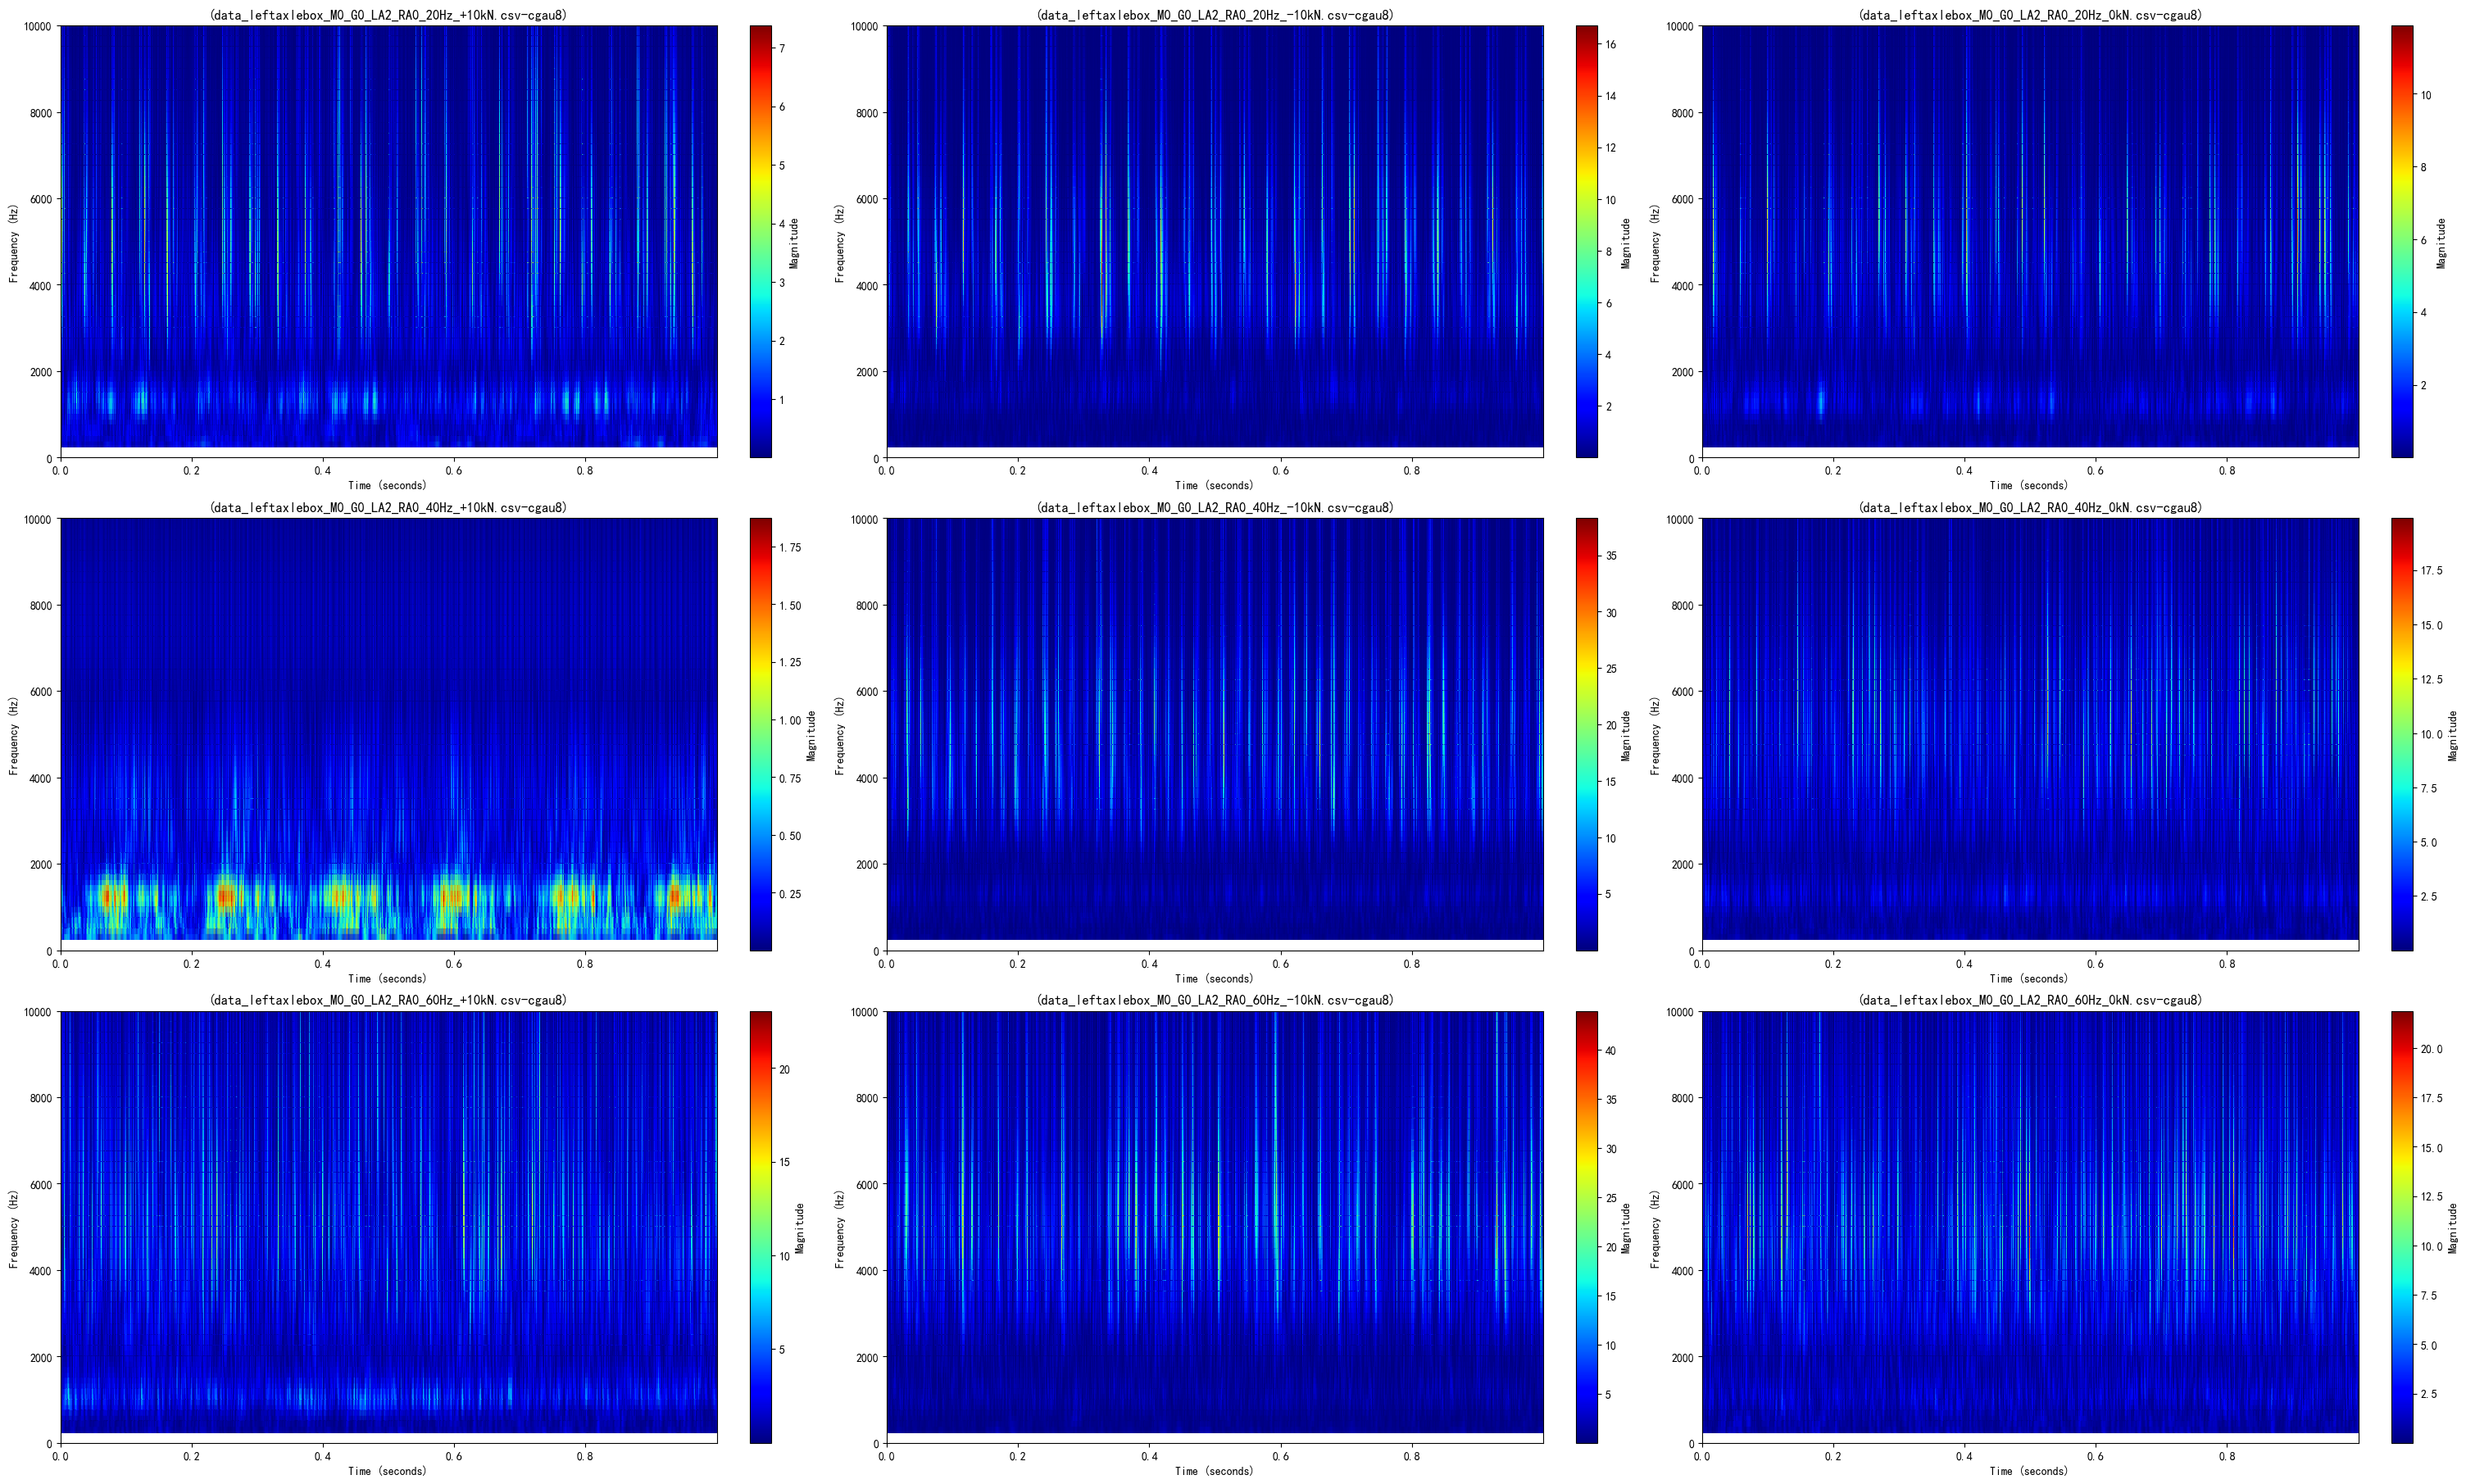

In [40]:
process_folder(folder_path='../数据集/BJTU/外圈')

C:\Users\wwt29\AppData\Local\Temp\ipykernel_25348\3223574779.py:26: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
D:\anaconda\envs\pytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


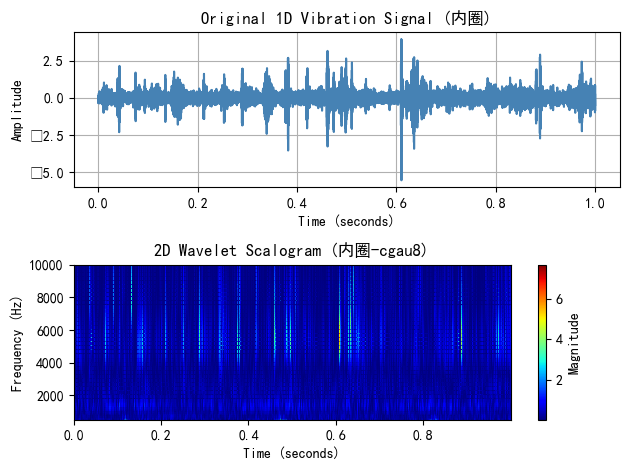

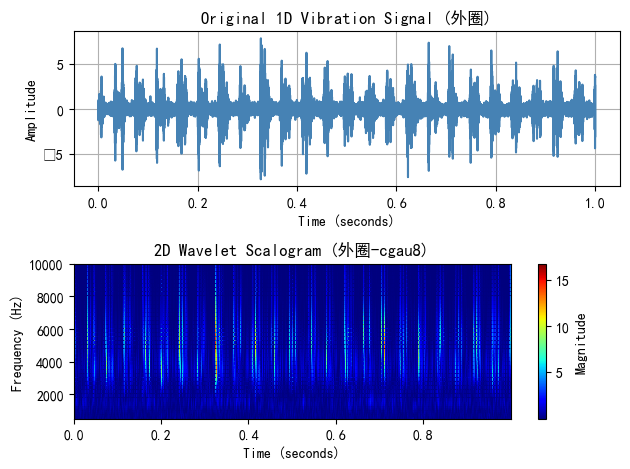

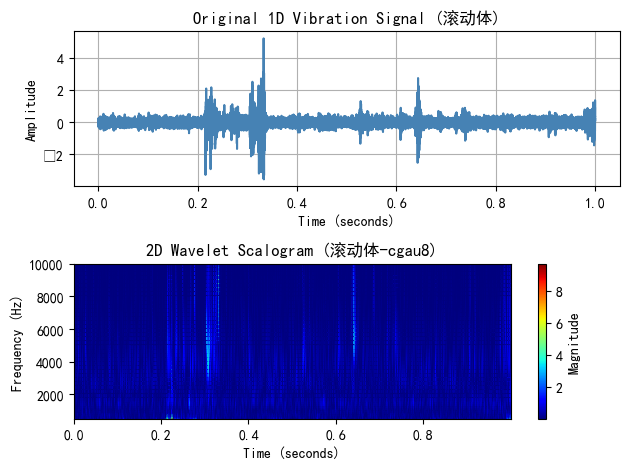

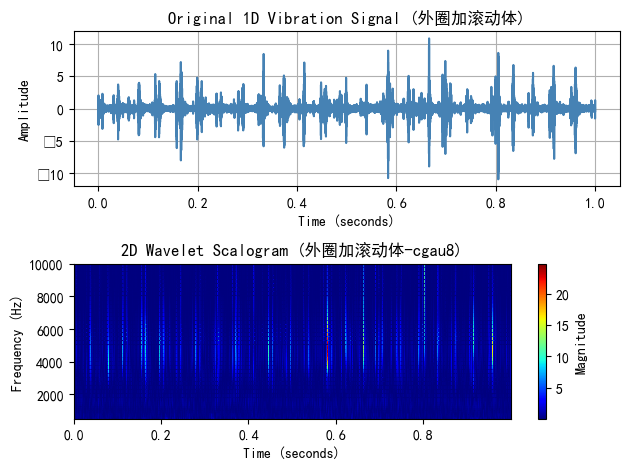

In [43]:
#相同工况下处理不同故障
data1=data_load('../数据集/BJTU/内圈/data_leftaxlebox_M0_G0_LA1_RA0_20Hz_-10kN.csv')[:64000]
data2=data_load('../数据集/BJTU/外圈/data_leftaxlebox_M0_G0_LA2_RA0_20Hz_-10kN.csv')[:64000]
data3=data_load('../数据集/BJTU/滚动体/data_leftaxlebox_M0_G0_LA3_RA0_20Hz_-10kN.csv')[:64000]
data4=data_load('../数据集/BJTU/外圈加滚动体/data_leftaxlebox_M0_G0_LA2+LA3_RA0_20Hz_-10kN.csv')[:64000]

data=[data1,data2,data3,data4]
faultname=['内圈','外圈','滚动体','外圈加滚动体']
def plot(wavename,faultname,data,frequencies,amplitude_scalogram):
    plt.subplot(2, 1, 1)
    t = np.linspace(0, 1, fs, endpoint=False)
    plt.plot(t, data, color='steelblue')
    plt.title(f"Original 1D Vibration Signal ({faultname})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    # 绘制小波变换后的二维时频图 (Scalogram)
    plt.subplot(2, 1, 2)
    # 使用 pcolormesh 绘制热力图
    plt.pcolormesh(t, frequencies, amplitude_scalogram, shading='gouraud', cmap='jet')
    plt.title(f"2D Wavelet Scalogram ({faultname}-{wavename})")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="Magnitude")
    plt.ylim(500,10000) # 把上限从 60000 多压到 15000 左右（可根据实际亮斑位置微调）
    plt.tight_layout()
    plt.show()


for i in range(4):
    frequencies,amplitude_scalogram=select_pywt(data[i],'cgau8')
    plot('cgau8',faultname[i],data[i], frequencies, amplitude_scalogram)